# Altair (`altair.40`) - ticker-level return attribution

Per-ticker decomposition of Altair's daily return over the recent drawdown
window `2026-05-03 -> 2026-05-11` and the last 30 calendar days.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown
from unravel_client import (
    get_portfolio_historical_weights,
    get_portfolio_returns,
    get_prices,
)

from analysis.utils import get_env

pd.options.display.float_format = "{:,.4f}".format

## Parameters

In [2]:
PORTFOLIO_ID = "altair.40"
START_DATE = "2020-01-01"

EVENT_START = "2026-05-03"
EVENT_END = "2026-05-11"

# Tables show TOP_N detractors and TOP_N contributors; charts show
# TOP_N // 2 of each.
TOP_N = 10
TX_COST = 0.0005

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")
if not UNRAVEL_API_KEY:
    msg = "Set UNRAVEL_API_KEY in your environment before running this notebook."
    raise ValueError(msg)

## Data

In [3]:
returns = get_portfolio_returns(
    id=PORTFOLIO_ID,
    api_key=UNRAVEL_API_KEY,
    start_date=START_DATE,
).dropna()
returns.index = pd.to_datetime(returns.index)
returns = returns.sort_index().rename("official_return")

weights = get_portfolio_historical_weights(
    id=PORTFOLIO_ID,
    api_key=UNRAVEL_API_KEY,
    start_date=START_DATE,
)
weights.index = pd.to_datetime(weights.index)
weights = weights.sort_index()
last_weight_publish = weights.index.max()

prices = get_prices(
    tickers=weights.columns.tolist(),
    api_key=UNRAVEL_API_KEY,
    start_date=START_DATE,
)
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

asset_returns = prices.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
common_idx = returns.index.intersection(asset_returns.index)
returns = returns.loc[common_idx]
asset_returns = asset_returns.loc[common_idx].fillna(0.0)
weights = weights.reindex(common_idx).fillna(0.0)

print(
    f"Sample range:                  {returns.index.min().date()} -> "
    f"{returns.index.max().date()}"
)
print(f"Most recent weight publish:    {last_weight_publish.date()}")
attribution_lag = (returns.index.max() - last_weight_publish).days
if attribution_lag > 1:
    print(
        f"Weights lag returns by {attribution_lag} day(s); the last "
        f"{attribution_lag - 1} return(s) cannot be attributed."
    )

Sample range:                  2020-01-01 -> 2026-05-12
Most recent weight publish:    2026-05-11


In [4]:
effective_weights = weights.shift(1).fillna(0.0)
daily_turnover = weights.diff(1).abs().fillna(0.0)
daily_contrib = (
    effective_weights.mul(asset_returns).sub(TX_COST * daily_turnover)
).reindex(returns.index).fillna(0.0)
daily_residual = (returns - daily_contrib.sum(axis=1)).rename("RESIDUAL")

## Drawdown window - top contributors and detractors

`share_of_event_return` is the ticker's arithmetic contribution divided by
the portfolio's arithmetic return over the window (positive = same
direction as the portfolio; negative = offsetting move).

In [5]:
event_start = pd.Timestamp(EVENT_START)
event_end = pd.Timestamp(EVENT_END)
event = returns.loc[event_start:event_end]
event_return_compound = (1 + event).prod() - 1
event_return_arith = event.sum()

event_contrib = daily_contrib.loc[event_start:event_end].sum()
event_residual = daily_residual.loc[event_start:event_end].sum()
event_token_return = (1 + asset_returns.loc[event_start:event_end].fillna(0)).prod() - 1

latest_publish_in_window = min(event_end, last_weight_publish)
end_weights = weights.loc[latest_publish_in_window]

event_share = (
    event_contrib / event_return_arith
    if not np.isclose(event_return_arith, 0.0)
    else pd.Series(np.nan, index=event_contrib.index)
)

event_table = pd.DataFrame(
    {
        "event_contribution": event_contrib,
        "share_of_event_return": event_share,
        "end_weight": end_weights,
        "event_token_return": event_token_return,
    }
).sort_values("event_contribution")

Markdown(
    f"### {event_start.date()} -> {event_end.date()}\n\n"
    f"| | |\n|---|---|\n"
    f"| Portfolio return (compounded) | **{event_return_compound:.2%}** |\n"
    f"| Sum of daily portfolio returns (arithmetic) | "
    f"**{event_return_arith:.2%}** |\n"
    f"| Sum of daily ticker contributions | "
    f"**{event_contrib.sum():.2%}** |\n"
    f"| Residual | **{event_residual:.2%}** |"
)

### 2026-05-03 -> 2026-05-11

| | |
|---|---|
| Portfolio return (compounded) | **-12.43%** |
| Sum of daily portfolio returns (arithmetic) | **-13.00%** |
| Sum of daily ticker contributions | **-13.00%** |
| Residual | **-0.00%** |

**Top detractors**

In [6]:
event_table.head(TOP_N)

,event_contribution,share_of_event_return,end_weight,event_token_return
TON,-0.0637,0.4901,0.0000,0.8070
ICP,-0.0277,0.2132,-0.0293,0.4088
ONDO,-0.0247,0.1899,0.0000,0.5205
SUI,-0.0153,0.1180,0.0000,0.3936
ENA,-0.0147,0.1132,-0.0596,0.2549
WLFI,-0.0142,0.1089,-0.0687,0.2057
ETC,-0.0083,0.0635,-0.0445,0.1479
WLD,-0.0077,0.0590,-0.0540,0.1480
AAVE,-0.0064,0.0492,-0.0747,0.0874
UNI,-0.0062,0.0477,-0.0331,0.1975


**Top contributors**

In [7]:
event_table.tail(TOP_N).iloc[::-1]

,event_contribution,share_of_event_return,end_weight,event_token_return
ZEC,0.0171,-0.1316,0.0435,0.4318
TRX,0.0145,-0.1115,0.2368,0.0634
SOL,0.0104,-0.0799,0.0892,0.1531
ALGO,0.0075,-0.0576,0.0785,0.0897
JST,0.0069,-0.0529,0.1056,0.0405
BTC,0.0053,-0.0409,0.1385,0.0391
BNB,0.0052,-0.0396,0.0632,0.0845
XMR,0.0051,-0.0395,0.0401,0.0849
ADA,0.0047,-0.0365,0.0403,0.1213
LINK,0.0031,-0.0242,0.0428,0.1542


## Cumulative contribution - drawdown window

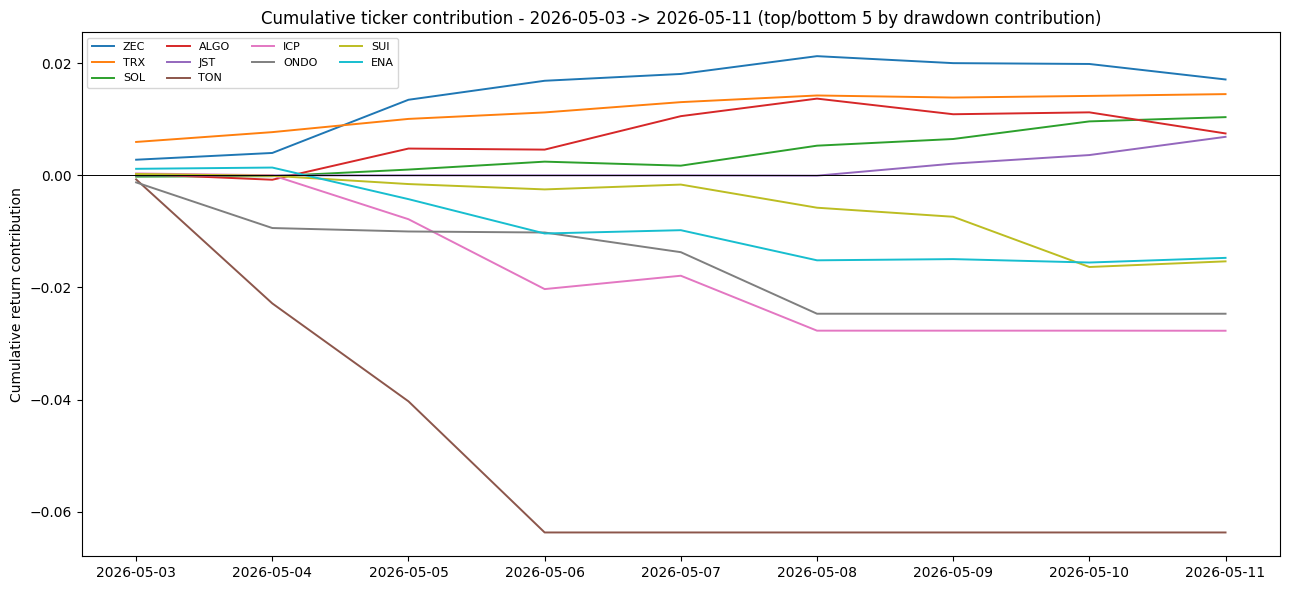

In [8]:
event_top_tickers = (
    event_contrib.nlargest(TOP_N // 2).index.tolist()
    + event_contrib.nsmallest(TOP_N // 2).index.tolist()
)
event_window_cum = daily_contrib.loc[event_start:event_end, event_top_tickers].cumsum()

plt.figure(figsize=(13, 6))
for ticker in event_top_tickers:
    plt.plot(
        event_window_cum.index, event_window_cum[ticker], label=ticker, linewidth=1.4
    )
plt.axhline(0, color="black", linewidth=0.7)
plt.title(
    f"Cumulative ticker contribution - {event_start.date()} -> "
    f"{event_end.date()} (top/bottom {TOP_N // 2} by drawdown contribution)"
)
plt.ylabel("Cumulative return contribution")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Cumulative contribution - last 30 calendar days

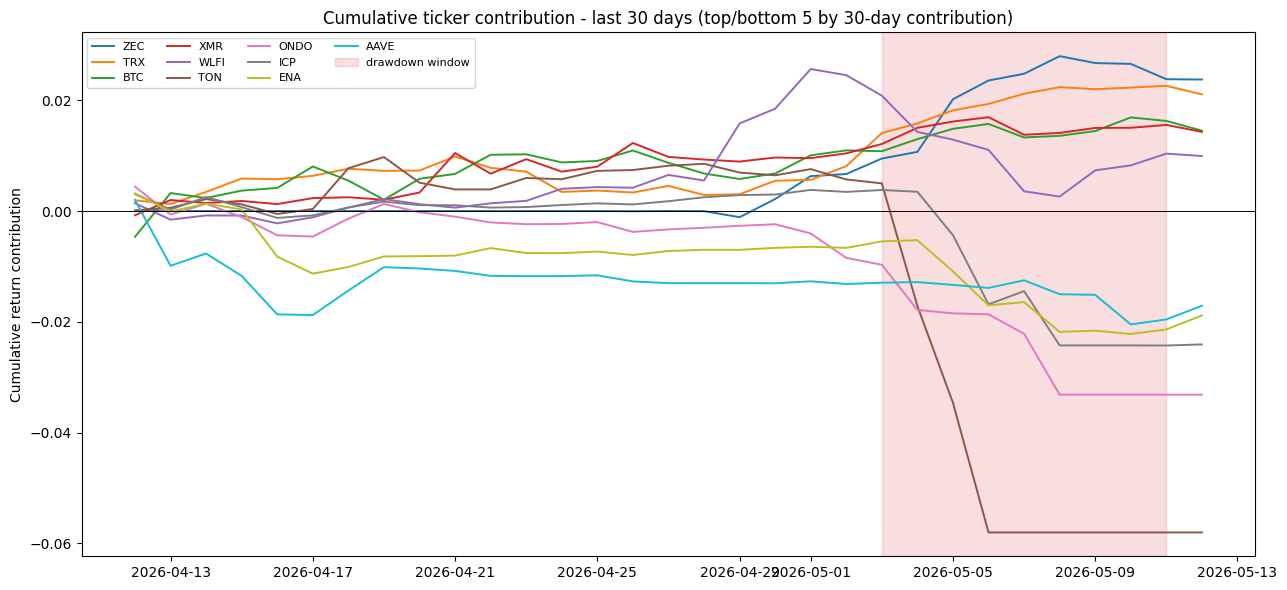

In [9]:
last_30_start = returns.index.max() - pd.Timedelta(days=30)
last_30_contrib = daily_contrib.loc[last_30_start:]
last_30_total = last_30_contrib.sum()
last_30_top = (
    last_30_total.nlargest(TOP_N // 2).index.tolist()
    + last_30_total.nsmallest(TOP_N // 2).index.tolist()
)
last_30_cum = last_30_contrib[last_30_top].cumsum()

plt.figure(figsize=(13, 6))
for ticker in last_30_top:
    plt.plot(last_30_cum.index, last_30_cum[ticker], label=ticker, linewidth=1.4)
plt.axvspan(
    event_start, event_end, color="tab:red", alpha=0.15, label="drawdown window"
)
plt.axhline(0, color="black", linewidth=0.7)
plt.title(
    f"Cumulative ticker contribution - last 30 days "
    f"(top/bottom {TOP_N // 2} by 30-day contribution)"
)
plt.ylabel("Cumulative return contribution")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Notes

- Contributions and residuals are summed arithmetically across days; the
  gap vs the compounded portfolio return is shown in the drawdown header.
- `event_token_return` in the table is the compounded return of the
  underlying token over the drawdown window, independent of portfolio weight.